# 1. Giải nén dataset và hiển thị thông tin dữ liệu
Đoạn code dưới đây sẽ tự động giải nén file `dataset.zip` (nếu chưa được giải nén) và thống kê số lượng ảnh thật/giả trong dữ liệu.

In [18]:
import os
import zipfile
from pathlib import Path

# Cấu hình đường dẫn
DATASET_ZIP = "../datasets/dataset.zip"
EXTRACT_DIR = "../datasets/extracted_data"

# 1. Giải nén dataset
if not os.path.exists(EXTRACT_DIR):
    print(f"Đang giải nén {DATASET_ZIP} vào {EXTRACT_DIR}...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Giải nén hoàn tất!")
else:
    print(f"Dữ liệu đã được giải nén tại {EXTRACT_DIR}.")

# 2. Hiển thị thông tin dữ liệu (số lượng ảnh theo thư mục)
print("\n--- Thông tin Data ---")
extracted_path = Path(EXTRACT_DIR)
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
total_images = 0

# Duyệt qua các thư mục con trong 'images'
for real_fake_dir in sorted(extracted_path.glob("images/*")):
    if real_fake_dir.is_dir():
        print(f"\nPhân loại: {real_fake_dir.name}")
        for category_dir in sorted(real_fake_dir.iterdir()):
            if category_dir.is_dir():
                images_count = sum(
                    1 for file in category_dir.iterdir() 
                    if file.suffix.lower() in image_extensions
                )
                print(f"  - {category_dir.name}: {images_count} ảnh")
                total_images += images_count

print(f"\nTổng số ảnh trong dataset: {total_images} ảnh")

Dữ liệu đã được giải nén tại ../datasets/extracted_data.

--- Thông tin Data ---

Phân loại: fake
  - FLUX_DEV: 7273 ảnh
  - FLUX_PRO: 3209 ảnh
  - SDXL: 53087 ảnh

Phân loại: real

Phân loại: test

Tổng số ảnh trong dataset: 63569 ảnh


# 2. Xóa bỏ DIRE, Chuẩn bị Dữ liệu (Train/Val Split) cho Ảnh Thật/Giả
Thay vì sử dụng phương pháp DIRE rất chậm chạp, chúng ta sẽ gộp tất cả ảnh thật (Real - Nhãn 0) và ảnh giả (Fake - Nhãn 1) lại thành một danh sách dữ liệu. Sau đó chia (split) tập dữ liệu này thành 80% để Huấn luyện (Train), 10% để Đánh giá tinh chỉnh (Validation) và 10% để Kiểm tra cuối cùng (Test) cho mô hình ResNet/ViT.

In [19]:
import os
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

EXTRACT_DIR = "../datasets/extracted_data"
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

dataset_info = []

# 1. Thu thập ảnh Real (Nhãn 0)
real_dir = Path(EXTRACT_DIR) / "images" / "real"
for img_path in real_dir.rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        dataset_info.append({"path": str(img_path.resolve()), "label": 0, "classname": "real"})

# 2. Thu thập ảnh Fake (Nhãn 1)
# Dùng rglob để duyệt tất cả thư mục con nằm trong fake (ví dụ: SDXL, Midjourney...)
fake_dir = Path(EXTRACT_DIR) / "images" / "fake"
for img_path in fake_dir.rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        dataset_info.append({"path": str(img_path.resolve()), "label": 1, "classname": "fake"})

# 3. Chuyển thành DataFrame để thống kê và phân chia dễ dàng
df = pd.DataFrame(dataset_info)
print(f"Tổng số ảnh thu thập được: {len(df)} ảnh.")
print("\nMật độ phân bổ nhãn:")
print(df['classname'].value_counts())

# 4. Chia Train / Val / Test (80% - 10% - 10%)
# Tham số stratify=df['label'] giúp chia đều nhãn Real/Fake
# Lần 1: Chia 80% Train, 20% còn lại (Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
# Lần 2: Cắt đôi 20% còn lại (thành 10% Val và 10% Test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\n✅ Số lượng ảnh tập Train (Huấn luyện): {len(train_df)} ảnh")
print(f"✅ Số lượng ảnh tập Validation (Đánh giá & Tinh chỉnh): {len(val_df)} ảnh")
print(f"✅ Số lượng ảnh tập Test (Kiểm tra cuối cùng): {len(test_df)} ảnh")

# Lưu lại DataFrame xuống file CSV tham chiếu cho các hàm sau
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)
print("\nĐã lưu danh mục dữ liệu phân chia thành các file CSV thành công.")

Tổng số ảnh thu thập được: 133569 ảnh.

Mật độ phân bổ nhãn:
classname
real    70000
fake    63569
Name: count, dtype: int64

✅ Số lượng ảnh tập Train (Huấn luyện): 106855 ảnh
✅ Số lượng ảnh tập Validation (Đánh giá & Tinh chỉnh): 13357 ảnh
✅ Số lượng ảnh tập Test (Kiểm tra cuối cùng): 13357 ảnh

Đã lưu danh mục dữ liệu phân chia thành các file CSV thành công.


# 3. Cấu hình PyTorch Dataset & DataLoader
Xây dựng Custom Dataset của PyTorch lấy thông tin đường dẫn và nhãn từ `train_split.csv` và `val_split.csv`. 
Quá trình này cũng sử dụng `torchvision.transforms` để thực hiện Augmentation (Lật, thay đổi màu sắc..) giúp thu thập những dạng nhiễu ảnh AI đa dạng và tránh tình trạng mô hình học vẹt (overfitting).

In [20]:
import cv2
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd # Đảm bảo pandas đã được import

# Định nghĩa các biến đổi (Augmentation) để tránh mô hình học vẹt
# Chú ý resize về 224x224 - đây là kiến trúc chuẩn cho các mô hình của ImageNet.
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Lật ngang 50% thời gian
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), # Dao động nhẹ về màu
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Thông số Mean mặc định của ImageNet
                         std=[0.229, 0.224, 0.225])   # Thông số Std mặc định của ImageNet
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Class Tự định nghĩa PyTorch Dataset
class RealFakeDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['path']
        label = self.data.iloc[idx]['label']
        
        # Load hình ảnh bằng PIL - convert RGBA sang RGB để tương thích ResNet
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            # Xử lý trường hợp có file lỗi/hỏng trong dataset
            print(f"Lỗi load ảnh: {img_path} - {e}")
            image = Image.new('RGB', (224, 224), (255, 255, 255))
            
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# Khởi tạo hai bộ dữ liệu (Datasets)
train_dataset = RealFakeDataset(csv_file="train_split.csv", transform=train_transforms)
val_dataset = RealFakeDataset(csv_file="val_split.csv", transform=val_transforms)
test_dataset = RealFakeDataset(csv_file="test_split.csv", transform=val_transforms)

# Khởi tạo DataLoader - Nhóm các ảnh vào thành từng Gói (Batch) ví dụ như 32 ảnh một lúc
# GIẢI QUYẾT LỖI MULTIPROCESSING TRÊN MAC BẰNG CÁCH SET num_workers=0
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Chức năng nạp dữ liệu hoàn tất! Train Loader: {len(train_loader)} batches | Val Loader: {len(val_loader)} batches | Test Loader: {len(test_loader)} batches.")

Chức năng nạp dữ liệu hoàn tất! Train Loader: 3340 batches | Val Loader: 418 batches | Test Loader: 418 batches.


# 4. Khởi tạo & Cấu hình Mô hình (Model Setup)
Sử dụng kiến trúc mạng `ResNet50` mạnh mẽ. Thay vì cho nó đoán 1000 con vật (ImageNet mặc định), chúng ta thay thế lớp kết luận cuối cùng (Fully Connected layer) của nó thành một ngã rẽ có đúng 2 lối: Real hoặc Fake. Việc này được gọi là "Transfer Learning".

In [21]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# 1. Xác định thiết bị tính toán của máy (MPS cho Mac Apple Silicon)
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Bắt đầu khởi tạo trên nền thiết bị: {device}")

# 2. Tải pretrained model ResNet50 từ Pytorch ImageNet
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# GIẢI PHÁP TĂNG TỐC X5 LẦN: ĐÓNG BĂNG MÔ HÌNH (FREEZE BACKBONE)
# Thay vì bắt máy cập nhật đạo hàm cho toàn bộ 25 triệu tham số, chúng ta khóa chúng lại hết!
# Việc này giúp máy Mac tiết kiệm rất nhiều VRAM và thời gian Train.
for param in model.parameters():
    param.requires_grad = False

# 3. Thay đổi lớp cuối: Resnet50 mặc định in_features=2048, trả ra 1000 con số (ImageNet).
# Gắn lại layer cuối: in_features=2048 trả ra đúng 2 kết quả là (Real, Fake)
# PyTorch khi tạo lớp Linear mới sẽ mặc định mở (Requires_grad = True) cho riêng lớp này
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

# Đưa cả bản vẽ mô hình này lên GPU/MPS
model = model.to(device)

print("Tập hợp mô hình ResNet50 và Đóng băng tham số hoàn thành!")

Bắt đầu khởi tạo trên nền thiết bị: mps
Tập hợp mô hình ResNet50 và Đóng băng tham số hoàn thành!


# 5. Xây dựng Vòng lặp Huấn luyện và Đánh giá (Training & Validation Phases)
Đây là quy trình bắt buộc trong Học Máy (Machine Learning Workflow):

**Bước 1: Huấn luyện (Training Phase):** 
Đưa tập Train (70% ảnh) vào. Thuật toán sẽ tính toán sai số (Loss) và tự cập nhật lại mạng lưới để bám sát dữ liệu (giảm Error).

**Bước 2: Đánh giá & Tinh chỉnh (Validation Phase):** 
Sau khi xong mỗi Epoch, chúng ta liền đưa tập Validation (10%) vào để kiểm tra. 
Quan trọng: Mô hình sẽ hoàn toàn Không học (No_Grad) từ tập ảnh này, nó chỉ "đoán". Kết quả này giúp chúng ta đánh giá độ thông minh và tinh chỉnh (hyperparameter tuning). Lặp lại 2 bước này cho đến khi ưng ý và lưu phiên bản tốt nhất!

/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 Khởi động huấn luyện - 10 Epochs!


Epoch 1/10 [Train]:   0%|          | 0/3340 [00:00<?, ?it/s]/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/10 [Val]:   0%|          | 0/418 [00:00<?, ?it/s]                           /Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


| Epoch [1/10] - ⏱️ Time: 803s - 💡 Train Loss: 0.0456, Acc: 98.49% | ⚖️ Val Loss: 0.0148, Acc: 99.52% |


Epoch 2/10 [Train]:   0%|          | 0/3340 [00:00<?, ?it/s]/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

| Epoch [6/10] - ⏱️ Time: 805s - 💡 Train Loss: 0.0185, Acc: 99.34% | ⚖️ Val Loss: 0.0089, Acc: 99.72% |


| Epoch [7/10] - ⏱️ Time: 802s - 💡 Train Loss: 0.0170, Acc: 99.41% | ⚖️ Val Loss: 0.0049, Acc: 99.84% |


| Epoch [8/10] - ⏱️ Time: 802s - 💡 Train Loss: 0.0167, Acc: 99.41% | ⚖️ Val Loss: 0.0081, Acc: 99.77% |


| Epoch [9/10] - ⏱️ Time: 800s - 💡 Train Loss: 0.0156, Acc: 99.47% | ⚖️ Val Loss: 0.0111, Acc: 99.59% |


| Epoch [10/10] - ⏱️ Time: 802s - 💡 Train Loss: 0.0167, Acc: 99.42% | ⚖️ Val Loss: 0.0057, Acc: 99.84% |

🎉 Quá trình Train & Val hoàn tất! Cột mốc tốt nhất ghi nhận: 99.84%



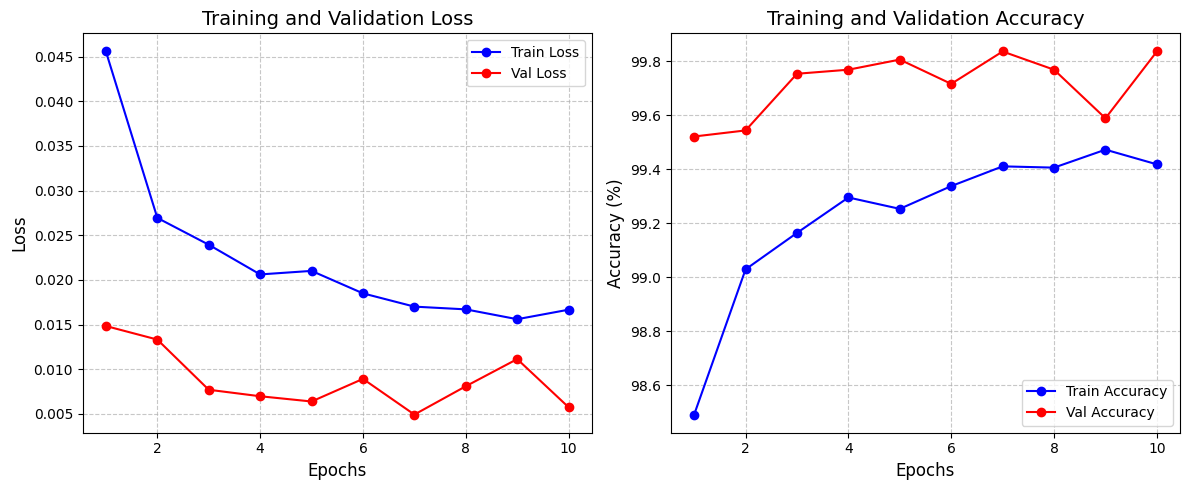

In [22]:
import time
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Thư viện vẽ thanh tiến trình

# Cấu hình Hàm Loss và Thuật Toán Tối Ưu (Optimizer)
criterion = nn.CrossEntropyLoss()

# Optimizer CHỈ mài giũa 1 lớp duy nhất là `model.fc`
optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-2)

# Vòng lặp: Chỉnh num_epochs = 10 theo yêu cầu
num_epochs = 10 
best_val_acc = 0.0

print(f"\n🚀 Khởi động huấn luyện - {num_epochs} Epochs!")

# Khởi tạo lists lưu trữ lịch sử để vẽ biểu đồ
history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_acc = []

for epoch in range(num_epochs):
    start_time = time.time()
    
    # ===============================
    # BƯỚC 1: HUẤN LUYỆN (TRAINING PHASE)
    # ===============================
    model.train() # Bật lại chế độ Cập nhật Trọng số
    running_train_loss = 0.0
    correct_train = 0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for images, labels in train_progress:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()      # Reset đạo hàm
        outputs = model(images)    # Tính dự đoán (Forward)
        loss = criterion(outputs, labels) # Tính sai số
        
        loss.backward()            # Cập nhật ngược (Backward pass)
        optimizer.step()           # Điều chỉnh Model 
        
        running_train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels)
        
        train_progress.set_postfix({'loss': f"{loss.item():.4f}"})
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = correct_train.float() / len(train_dataset) * 100

    # ===============================
    # BƯỚC 2: ĐÁNH GIÁ (VALIDATION PHASE)
    # ===============================
    model.eval() # Tắt tính năng Cập nhật Trọng số (VRAM giảm mạnh)
    running_val_loss = 0.0
    correct_val = 0

    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)

    with torch.no_grad(): # Ngăn đạo hàm phát sinh trong lúc đánh giá
        for images, labels in val_progress:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels)
            
            val_progress.set_postfix({'loss': f"{loss.item():.4f}"})
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val.float() / len(val_dataset) * 100
    
    elapsed_time = time.time() - start_time

    # BÁO CÁO NHANH KẾT QUẢ VÒNG LẶP NÀY
    print(f"| Epoch [{epoch+1}/{num_epochs}] - "
          f"⏱️ Time: {elapsed_time:.0f}s - "
          f"💡 Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"⚖️ Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% |")

    # Lưu lại vào lịch sử để vẽ biểu đồ
    history_train_loss.append(epoch_train_loss)
    history_train_acc.append(epoch_train_acc.cpu().item())
    history_val_loss.append(epoch_val_loss)
    history_val_acc.append(epoch_val_acc.cpu().item())

    # LƯU TRẠNG THÁI TỐT NHẤT DỰA TRÊN TẬP VAL
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "resnet50_best_real_fake.pth")

print(f"\n🎉 Quá trình Train & Val hoàn tất! Cột mốc tốt nhất ghi nhận: {best_val_acc:.2f}%\n")

# ===============================
# BƯỚC 3: VẼ BIỂU ĐỒ ACCURACY & LOSS
# ===============================
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_train_loss, label='Train Loss', marker='o', color='blue')
plt.plot(epochs_range, history_val_loss, label='Val Loss', marker='o', color='red')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_train_acc, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, history_val_acc, label='Val Accuracy', marker='o', color='red')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 6. Kiểm tra cuối cùng (Testing Phase & Confusion Matrix)
**Bước 3: Kiểm tra cuối cùng (Testing Phase):** 
Bây giờ, chúng ta sẽ Tải lại trọng số tốt nhất đã lưu ở Bước 2.

Đưa 15% lượng tập **Test** (Vốn dĩ nãy giờ Mô hình chưa từng được thấy mặt chúng, cũng không được dùng để điều chỉnh thông số Val) và chạy dự đoán một lần duy nhất. Nếu kết quả chạy mượt và ra Ma trận nhầm lẫn cao, Nghĩa là AI không hề bị "Học vẹt" hay thiên vị!

Đang đánh giá lại độ chính xác trên toàn bộ tập TEST cuối cùng...


Testing:   0%|          | 0/418 [00:00<?, ?it/s]/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                          

\n--- Báo Cáo Phân Loại (Classification Report) Trên Tập TEST ---
                 precision    recall  f1-score   support

REAL (Ảnh thật)       1.00      1.00      1.00      7000
  FAKE (Ảnh AI)       1.00      1.00      1.00      6357

       accuracy                           1.00     13357
      macro avg       1.00      1.00      1.00     13357
   weighted avg       1.00      1.00      1.00     13357



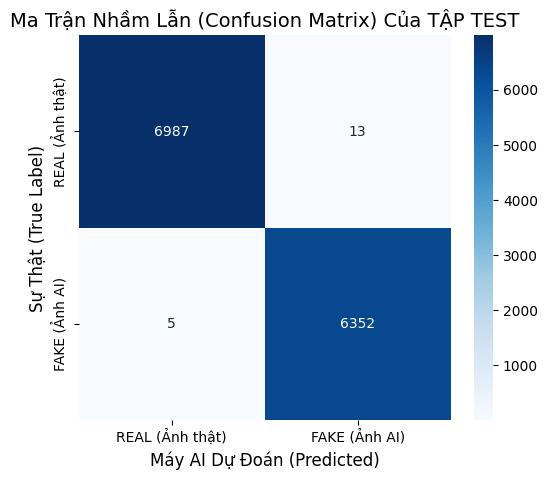

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# BƯỚC 3: TESTING (TẢI LẠI TRỌNG SỐ VÀ CHẠY TẬP TEST ĐỘ ĐỘC LẬP)
model.load_state_dict(torch.load("resnet50_best_real_fake.pth", weights_only=True))

model.eval()

y_true = []
y_pred = []

print("Đang đánh giá lại độ chính xác trên toàn bộ tập TEST cuối cùng...")
with torch.no_grad():
    # CHẠY TEST_LOADER (chứ KHÔNG PHẢI val_loader)
    test_progress = tqdm(test_loader, desc="Testing", leave=False)
    for images, labels in test_progress:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Chuyển đổi tensor về mảng numpy 1D để có thể đưa vào thư viện sklearn
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# BÁO CÁO PHÂN LOẠI REPORT: Xem thêm Precision, Recall cho từng Nhãn
target_names = ["REAL (Ảnh thật)", "FAKE (Ảnh AI)"]
print("\\n--- Báo Cáo Phân Loại (Classification Report) Trên Tập TEST ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# VẼ BẢNG MA TRẬN NHẦM LẪN (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Máy AI Dự Đoán (Predicted)', fontsize=12)
plt.ylabel('Sự Thật (True Label)', fontsize=12)
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) Của TẬP TEST', fontsize=14)
plt.show()

# 7. Thử Nghiệm Ứng Dụng (Inference)
Xây dựng một hàm tự động tải một bức ảnh bất kỳ từ ổ cứng truyền sang cho Trí Tuệ Nhân Tạo (AI) mà chúng ta vừa huấn luyện để xác định xem tỷ lệ nó đoán đó là ảnh Fake là bao nhiêu %. Mọi người có thể dễ dàng thay đổi đường dẫn của File tải từ mạng Internet về để sử dụng trực tiếp!

Tìm thấy 10 ảnh. Đang tiến hành dự đoán...



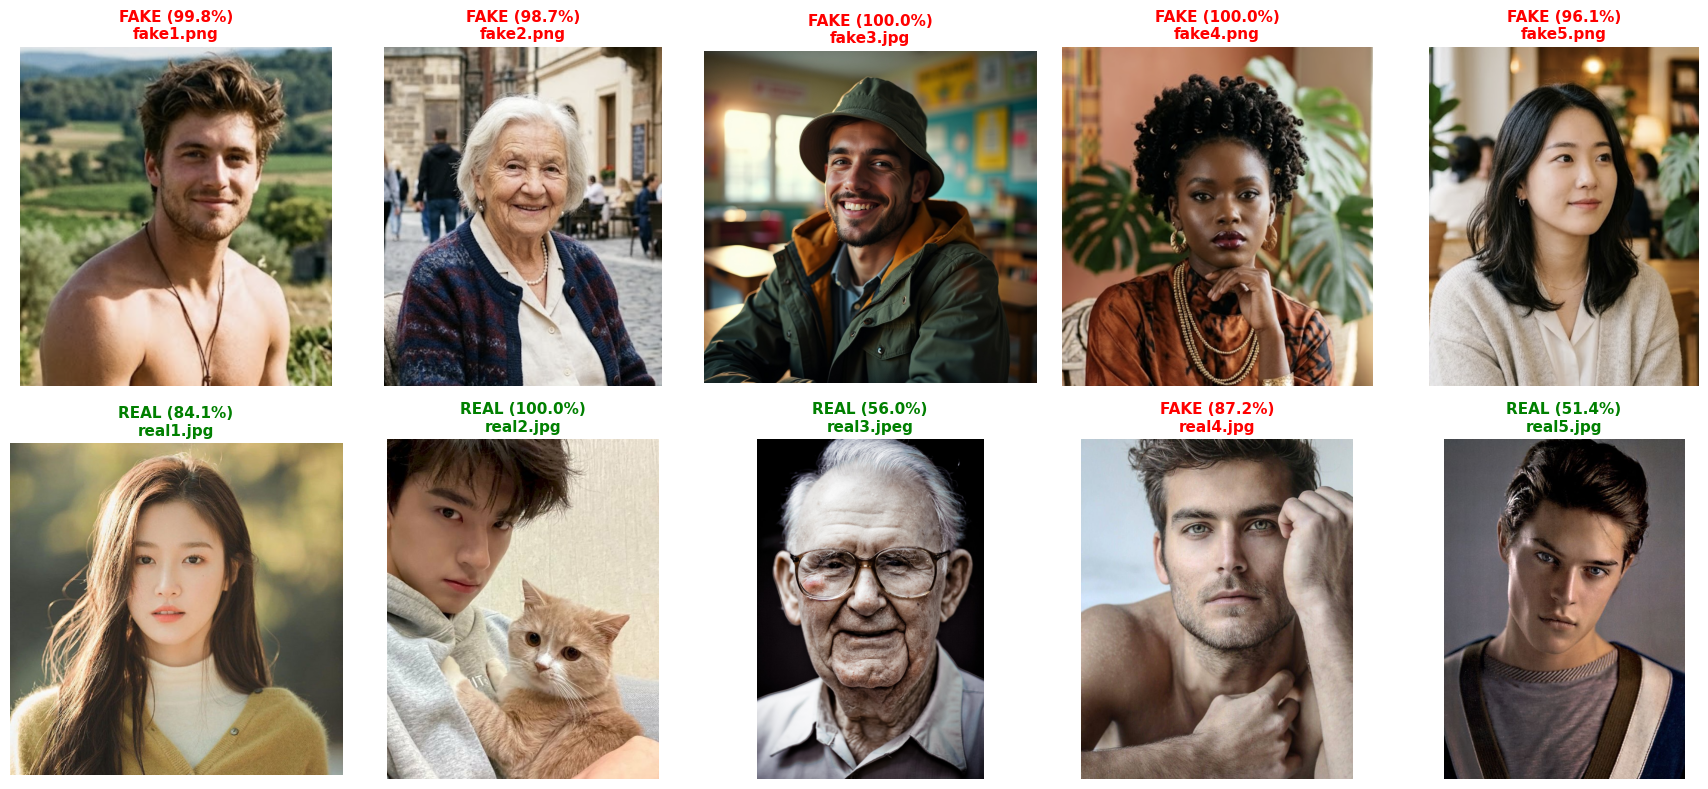

In [42]:
import os
import math
import torch
import torch.nn as nn
from torchvision.models import resnet50
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Xác định thiết bị và Tải bản vẽ mô hình
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

# Nạp cấu trúc model và Load trọng số từ file (không cần train lại)
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("resnet50_best_real_fake.pth", map_location=device, weights_only=True))
model = model.to(device)
model.eval()

# Tiền xử lý ẩn
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_images_in_folder(folder_path, max_cols=5):
    """
    Nhận đầu vào là một thư mục, quét tất cả các ảnh và hiển thị dự đoán theo dạng lưới.
    Tối đa {max_cols} ảnh trên mỗi dòng.
    """
    folder_dir = Path(folder_path)
    if not folder_dir.exists() or not folder_dir.is_dir():
        print(f"Thư mục {folder_path} không tồn tại hoặc không hợp lệ!")
        return
        
    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
    # Sắp xếp ảnh theo tên alphabet
    image_paths = sorted([p for p in folder_dir.iterdir() if p.suffix.lower() in image_extensions])
    
    num_images = len(image_paths)
    if num_images == 0:
        print(f"Không tìm thấy ảnh hợp lệ (jpg/png/webp) nào trong {folder_path}!")
        return
        
    print(f"Tìm thấy {num_images} ảnh. Đang tiến hành dự đoán...\n")
    
    # Tính toán số lượng dòng/cột hiển thị trên Matplotlib
    cols = min(max_cols, num_images)
    rows = math.ceil(num_images / cols)
    
    fig = plt.figure(figsize=(cols * 3.5, rows * 4))
    
    for i, img_path in enumerate(image_paths):
        try:
            img = Image.open(img_path).convert("RGB")
            
            # Ép ảnh về dạng Tensor ma trận (1, 3, 224, 224) để model đọc được
            img_tensor = preprocess(img).unsqueeze(0).to(device) 
            
            with torch.no_grad():
                outputs = model(img_tensor)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                confidence, predicted_class = torch.max(probabilities, 1)
                
            is_fake = predicted_class.item() == 1
            label = "FAKE" if is_fake else "REAL"
            score = confidence.item() * 100
            color = "red" if is_fake else "green"
            
            # Khởi tạo vùng vẽ từng ảnh (subplot)
            ax = fig.add_subplot(rows, cols, i + 1)
            ax.imshow(img)
            ax.axis('off')
            
            # Rút gọn tên file nếu quá dài (quá 15 ký tự thì thêm dấu ...)
            short_name = img_path.name if len(img_path.name) <= 15 else img_path.name[:12] + "..."
            ax.set_title(f"{label} ({score:.1f}%)\n{short_name}", color=color, fontsize=11, fontweight='bold')
            
        except Exception as e:
            print(f"Lỗi khi xử lý ảnh {img_path.name}: {e}")
            
    plt.tight_layout()
    plt.show()

# ==================================
# THỰC THI:
# Truyền vào bất kỳ đường dẫn thư mục ảnh nào bạn muốn
test_folder_path = "../datasets/extracted_data/images/test"

if os.path.exists(test_folder_path):
    predict_images_in_folder(test_folder_path, max_cols=5)
else:
    print("Vui lòng cập nhật đường dẫn thư mục hợp lệ tại biến test_folder_path!")